### Variant based investigation: 
- Data visualization of 3 aspects in the NGN2 CREs
  - Significant variant effects
  - Variant effect size grouping and distribution
  - 



In [124]:
import ast
import sys
import pandas as pd
import numpy as np # For potential NaN handling if needed
import os


sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
# from importlib import reload
# reload(hf)

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


import yaml

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()


has_readout_ngn2_col = "has_readout_NGN2"
has_readout_ngn2_col = "bcalm_variant_effect_data_exists"
is_significant_ngn2_col = "is_significant_NGN2"
variant_effect_adjusted_p_val_col = "bcalm_variant_effect_adjusted_p_value"
variant_effect_logfc_col = "bcalm_variant_effect_log_ratio_activity"
variant_id_col = "ID"

#### Preprocess the input data: 

In [55]:
# --- Configuration: Define file paths ---
significant_threshold = 0.1

# In a real scenario, these would be command-line arguments or config file entries
NGN2_RESULTS_PATH = config['files']['creating']['NGN2_variants_metadata_bcalm_2025_bbmap_normalized_counts']
input_directory = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/"
NGN2_RESULTS_PATH = os.path.join(input_directory, 'NGN2_variant_bcalm_80k_bbmap_no_outlier_removal_normalized_counts_mpralib_design_variant_map_unique_id_all_rep_DNA_RNA.tsv')
NGN2_RESULTS_PATH = os.path.join(input_directory, 'NGN2_variant_bcalm_80k_bbmap_selfmadeStrandSensitive_no_outlier_removal_normalized_counts_removed_additional_normalization_2025_05_mpralib_design_variant_map_unique_id_all_rep_DNA_RNA.tsv')

VARIANT_MAP_PATH = '/home/kisa/coding/80K_MPRA/server_results/80k_counts_after_metadatafile/unique_id_renamed_variant_region_map_mprasnakeflow_input_tilde2comma.tsv.gz'
METADATA_PATH = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/mpra_metadata_format/MPRA_80215.metadata.tsv.gz'
METADATA_PATH = '/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/notebooks/control_metadata/MPRA_80215.metadata.tsv.gz'

# --- output directory and path ---
# output_directory = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/"
# --- 1. Load Data ---
try:
    NGN2_df = pd.read_csv(NGN2_RESULTS_PATH, sep='\t')
    variant_map_df = pd.read_csv(VARIANT_MAP_PATH, sep='\t')
    metadata_df = pd.read_csv(METADATA_PATH, sep='\t')
    # use safe eval on list
    # Apply the safe_eval function to the specified columns
    for col in list_columns:
        metadata_df[col] = metadata_df[col].apply(safe_eval)
    print("All data files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure all TSV files are in the correct directory.")
    exit() # Exit if a critical file is missing



All data files loaded successfully.


In [56]:
# --- 2. Process variant_map as Base for final_df ---
# This ensures all variants from variant_map are in the final output
final_df = variant_map_df[['ID', 'REF', 'ALT']].copy()
print(f"Initial final_df created from variant_map with {len(final_df)} variants.")

# --- 3. Process Metadata Table ---

# IMPORTANT: Assuming 'category' column in metadata_df can distinguish 'reference' and 'alternative'
# You might need to adjust the filtering logic based on your actual metadata_df content.
# For example, if REF sequences have no 'variant_pos' or col_SPDI, you could use that.
# A common pattern is 'category' or 'class' describing the sequence type.

# Metadata for REF sequences (only 'sequence' needed as 'ref_seq')
metadata_ref = metadata_df[metadata_df['allele'].apply(hf.is_reference)].copy()
if metadata_ref.empty:
    print("Warning: No 'reference' category found in metadata. 'ref_seq' might be missing.")
metadata_ref = metadata_ref[['name', 'sequence', 'chr', 'start', 'end', 'strand']].rename(columns={
    'name': 'REF',
    'sequence': 'ref_seq'
})
print(f"Processed metadata for {len(metadata_ref)} REF sequences.")

# Metadata for ALT sequences ('sequence', 'variant_pos', 'SPDI' needed)
metadata_alt = metadata_df[metadata_df['allele'].apply(hf.is_alternative)].copy()
if metadata_alt.empty:
    print("Warning: No 'alternative' category found in metadata. 'alt_seq', 'variant_pos', 'SPDI' might be missing.")
metadata_alt = metadata_alt[['name', 'sequence', col_variant_pos, col_SPDI]].rename(columns={
    'name': 'ALT',
    'sequence': 'alt_seq'
})
print(f"Processed metadata for {len(metadata_alt)} ALT sequences.")


# --- 4. Merge Metadata onto final_df ---

# Merge ref_seq
final_df = pd.merge(final_df, metadata_ref, on='REF', how='left')
print(f"Merged REF metadata. Columns: {final_df.columns.tolist()}")

# Merge alt_seq, variant_pos, SPDI
final_df = pd.merge(final_df, metadata_alt, on='ALT', how='left')
print(f"Merged ALT metadata. Columns: {final_df.columns.tolist()}")

print(f"Number of variants after merging with metadata: {len(final_df)}")
# --- 5. Process and Merge Result Tables (NGN2 & undiffWTC11) ---

# Process NGN2 results
NGN2_processed = NGN2_df[['variant_id', 'adj.P.Val', 'logFC']].copy()
NGN2_processed.rename(columns={
    'adj.P.Val': 'adjusted_p-value_NGN2',
    'logFC': 'logFC_NGN2'
}, inplace=True)
NGN2_processed['has_readout_NGN2'] = True
print(f"Processed {len(NGN2_processed)} variants for NGN2 cell type.")

# Merge NGN2 results into final_df
final_df = pd.merge(final_df, NGN2_processed, left_on='ID', right_on='variant_id', how='left')
final_df.drop(columns=['variant_id'], inplace=True) # Drop the redundant ID column
print(f"Merged NGN2 results. Columns: {final_df.columns.tolist()}")

Initial final_df created from variant_map with 47044 variants.
Processed metadata for 18932 REF sequences.
Processed metadata for 47160 ALT sequences.
Merged REF metadata. Columns: ['ID', 'REF', 'ALT', 'ref_seq', 'chr', 'start', 'end', 'strand']
Merged ALT metadata. Columns: ['ID', 'REF', 'ALT', 'ref_seq', 'chr', 'start', 'end', 'strand', 'alt_seq', 'variant_pos', 'SPDI']
Number of variants after merging with metadata: 47044
Processed 39498 variants for NGN2 cell type.
Merged NGN2 results. Columns: ['ID', 'REF', 'ALT', 'ref_seq', 'chr', 'start', 'end', 'strand', 'alt_seq', 'variant_pos', 'SPDI', 'adjusted_p-value_NGN2', 'logFC_NGN2', 'has_readout_NGN2']


In [57]:
# --- 6. Handle Missing Readouts ---

# Fill NaN values for 'has_readout' columns with False
final_df['has_readout_NGN2'] = final_df['has_readout_NGN2'].fillna(0).astype('bool')
print("Filled NaN values for 'has_readout' columns with False.")

# NaN values in adjusted_p-value and logFC will remain, indicating no measurement.

# Make start and end int columns
final_df['start'] = final_df['start'].astype('Int64')  # Use Int64 for nullable integer
final_df['end'] = final_df['end'].astype('Int64')      # Use Int64 for nullable integer

# Handle SPDI and variant pos lists
# only get the first element from the SPDI column (list)
final_df[col_SPDI] = final_df[col_SPDI].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)

final_df[col_variant_pos] = final_df[col_variant_pos].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
# set to int
final_df[col_variant_pos] = final_df[col_variant_pos].astype('Int64')  # Use Int64 for nullable integer
# add is significant column
print("Significant threshold: ", significant_threshold)
final_df['is_significant_NGN2'] = final_df['adjusted_p-value_NGN2'] <= significant_threshold

# --- 7. Final Column Selection and Ordering ---

# Define the exact order of columns
desired_columns = [
    "ID",
    "REF",
    "ALT",
    "SPDI",
    "chr",
    "start",
    "end",
    "strand",
    "ref_seq",
    "alt_seq",
    "variant_pos",
    "adjusted_p-value_NGN2",
    "logFC_NGN2",
    "has_readout_NGN2",
    "is_significant_NGN2",
]

# Select and reorder columns
# Use .reindex to handle cases where a column might be missing, filling with NaN
final_df = final_df.reindex(columns=desired_columns)
print(f"Final column order and selection applied. Final shape: {final_df.shape}")

# # --- Display Final Results ---
# print("\n--- Final Overview Table (First 5 Rows) ---")
# print(final_df.head())

print("\n--- Final Table Info ---")
final_df.info()

print("\n--- Missing Values in Final Table (Count) ---")
print(final_df.isnull().sum())

# filter missing spdi rows out
final_df = final_df[final_df[col_SPDI].notna()].copy()
print(f"\nFiltered final_df to remove rows with missing SPDI. Remaining rows: {len(final_df)}")


# Optional: Save the final table to a new TSV file
# output_path = 'variant_overview_table.tsv'
# final_df.to_csv(output_path, sep='\t', index=False)
# print(f"\nFinal table saved to {output_path}")

Filled NaN values for 'has_readout' columns with False.
Significant threshold:  0.1
Final column order and selection applied. Final shape: (47044, 15)

--- Final Table Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47044 entries, 0 to 47043
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     47044 non-null  object 
 1   REF                    47044 non-null  object 
 2   ALT                    47044 non-null  object 
 3   SPDI                   47016 non-null  object 
 4   chr                    47016 non-null  object 
 5   start                  47016 non-null  Int64  
 6   end                    47016 non-null  Int64  
 7   strand                 47016 non-null  object 
 8   ref_seq                47016 non-null  object 
 9   alt_seq                47016 non-null  object 
 10  variant_pos            47016 non-null  Int64  
 11  adjusted_p-value_NGN2  39498 non-

In [58]:
# final_df_with_normalized_counts = final_df.copy()
final_df_with_removal_of_additional_normalized_counts = final_df.copy()


In [59]:
final_df.head()

,ID,REF,ALT,SPDI,chr,start,end,strand,ref_seq,alt_seq,variant_pos,adjusted_p-value_NGN2,logFC_NGN2,has_readout_NGN2,is_significant_NGN2
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2179590:T:C,chr1,2179507,2179777,+,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,83,NaN,NaN,False,False
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2191443:G:A,chr1,2191262,2191532,+,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,181,NaN,NaN,False,False
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2192014:G:T,chr1,2191971,2192241,+,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,43,NaN,NaN,False,False
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2192365:T:G,chr1,2192249,2192519,+,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,116,0.937457,-0.006802,True,False
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2193141:G:A,chr1,2192936,2193206,+,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,205,0.942361,-0.005216,True,False


In [60]:
final_df["has_readout_NGN2"].sum() # 39498
# final_df["ID"].nunique()
final_df.loc[final_df["has_readout_NGN2"]]["ID"].nunique() # 39498

39498

In [61]:
final_df_with_normalized_counts["has_readout_NGN2"].sum()

final_df_with_normalized_counts_ids = set(list(final_df_with_normalized_counts.loc[final_df_with_normalized_counts["has_readout_NGN2"]]["ID"].unique()))

In [62]:
final_df_with_removal_of_additional_normalized_counts["has_readout_NGN2"].sum()
final_df_with_removal_of_additional_normalized_counts_ids = set(list(final_df_with_removal_of_additional_normalized_counts.loc[final_df_with_removal_of_additional_normalized_counts["has_readout_NGN2"]]["ID"].unique()))

In [63]:
len(final_df_with_removal_of_additional_normalized_counts_ids)

39498

In [64]:
missing_ids_from_first_normalized_set = final_df_with_removal_of_additional_normalized_counts_ids - final_df_with_normalized_counts_ids
missing_ids_from_first_normalized_set

{'cardiac_neuro_cava_random:ALT_B3GNT9|ENSG00000237172.4|EH38E1822727_rev_tile1-1_B3GNT9|ENSG00000237172.4|EH38E1822727|16-67194520-A-T',
 'cardiac_neuro_cava_random:ALT_SLC22A5|ENSG00000197375.14|EH38E3660472_fwd_tile1-1_SLC22A5|ENSG00000197375.14|EH38E3660472|5-132371845-A-G',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166944,TCF20|ENSG00000100207.21|EH38E2166944_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166944|22-42180465-G-A',
 'cardiac_neuro_cava_random:ALT_RTN4R|ENSG00000040608.14|EH38E3468335_rev_tile1-1_RTN4R|ENSG00000040608.14|EH38E3468335|22-20271188-A-C',
 'cardiac_neuro_cava_random:ALT_EEF1A2|ENSG00000101210.13|EH38E3448787,KCNQ2|ENSG00000075043.20|EH38E3448787_rev_tile1-1_EEF1A2|ENSG00000101210.13|EH38E3448787|20-63469110-C-G,KCNQ2|ENSG00000075043.20|EH38E3448787|20-63469110-C-G',
 'cardiac_neuro_cava_random:ALT_MBOAT7|ENSG00000125505.17|EH38E3316466_rev_tile1-1_CNOT3|ENSG00000088038.20|EH38E3316466|19-54136328-C-T,MBOAT7|ENSG00000125505.17|EH38E3316

#### Read the variant metadata file directly with gnomad info (used for the ISMB 2025 submission)

In [70]:
import pandas as pd
variant_info_80k = pd.read_csv("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/NGN2_variants_metadata_with_bcalm_2025_04_bbmap_normalized_counts.tsv.gz", sep="\t", low_memory=False)
variant_info_80k

variant_info_80k[col_variant_pos] = variant_info_80k[col_variant_pos].apply(safe_eval)

In [71]:
gnomad_info_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/variants_metadata_with_bcalm_2025_02_bbmap_scrambled_gnomad_info.tsv.gz"
gnomad_info = pd.read_csv(gnomad_info_path, sep="\t", low_memory=False)
gnomad_info

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_ref,gnomad_alt,gnomad_AC,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,...,T,C,71917.0,0.472883,0.667391,0.347516,0.393314,0.37656,0.667391,0.374352
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,...,G,A,2617.0,0.017203,0.059656,0.000000,0.000147,0.00000,0.059656,0.000000
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,...,G,T,1.0,0.000007,0.000024,0.000000,0.000000,0.00000,0.000024,0.000000
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,...,T,G,1.0,0.000007,0.000015,0.000000,0.000015,0.00000,0.000000,0.000000
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,...,G,A,7205.0,0.047348,0.161114,0.000000,0.001000,0.00000,0.161114,0.000576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,...,A,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,...,T,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,...,C,T,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.615562,-0.284541,1.000000,...,G,A,2.0,0.000018,0.000561,0.000561,0.000000,0.00000,0.000000,0.000000


In [72]:
variant_info_80k_gnomad = variant_info_80k.merge(gnomad_info[["ALT", "gnomad_AC", "gnomad_AF"]], on="ALT", how="inner").copy()

In [79]:
variant_info_80k_gnomad_bcalm_exists = variant_info_80k_gnomad.loc[variant_info_80k_gnomad[f"{has_readout_ngn2_col}"]].copy()
variant_info_80k_gnomad_bcalm_exists[f"{is_significant_ngn2_col}"] = variant_info_80k_gnomad_bcalm_exists[f"{variant_effect_adjusted_p_val_col}"] < significant_threshold

In [80]:
variant_info_80k_gnomad_bcalm_exists.head()

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_AC,gnomad_AF,is_significant_NGN2
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.0,-0.068107,1.0,-0.072051,cardiac_neuro_cava_random,1.0,0.000007,False
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.0,0.001944,1.0,-0.005889,cardiac_neuro_cava_random,7205.0,0.047348,False
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.779710,-0.130556,1.0,-0.053109,1.0,-0.065999,cardiac_neuro_cava_random,1.0,0.000007,False
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.953076,-0.034817,1.0,-0.053109,1.0,-0.074918,cardiac_neuro_cava_random,4.0,0.000026,False
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.632794,-0.167928,1.0,-0.053109,1.0,-0.060033,cardiac_neuro_cava_random,6.0,0.000039,False


#### How many significant variants are there in NGN2?
- Number and plot them

In [82]:
print(f"Number of unique variants with readout in NGN2: {variant_info_80k_gnomad_bcalm_exists.loc[variant_info_80k_gnomad_bcalm_exists[f'{has_readout_ngn2_col}']][f'{variant_id_col}'].nunique()}")

Number of unique variants with readout in NGN2: 37870


In [83]:
# Print how many variants are significant:
print(f"Number of significant variants in NGN2: {variant_info_80k_gnomad_bcalm_exists[f'{is_significant_ngn2_col}'].sum()}") # 1212

Number of significant variants in NGN2: 1304


In [84]:
import matplotlib.pyplot as plt
import math
def plot_volcano(BCalm_table, title, logFC_col, adj_p_val_col, significants_niveau=0.1, ylim_max=11, ylim_min=-0.025, xlim_min=-1, xlim_max=1, sig_dot_size=8):
    BCalm_table['BCalm_true'] = np.where((BCalm_table[logFC_col] > 0) & (BCalm_table[adj_p_val_col] < significants_niveau), 'positive', 'neutral')
    BCalm_table['BCalm_true'] = np.where((BCalm_table[logFC_col] < 0) & (BCalm_table[adj_p_val_col] < significants_niveau), 'negative', BCalm_table['BCalm_true'])

    significant_BCalm_table = BCalm_table[BCalm_table[adj_p_val_col] < significants_niveau]
    up = BCalm_table[BCalm_table['BCalm_true'] == 'positive']
    down = BCalm_table[BCalm_table['BCalm_true'] == 'negative']

    plt.figure(figsize=(15,10))
    # make background dark for the plot
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    ax = plt.gca()
    plt.style.use("ggplot")
    plt.scatter(x=BCalm_table[logFC_col],y=BCalm_table[adj_p_val_col].apply(lambda x:-np.log10(x)),s=1,label=f"BCalm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
    plt.scatter(x=down[logFC_col],y=down[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="BCalm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
    plt.scatter(x=up[logFC_col],y=up[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="BCalm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
    # scatter for controls
    # plt.scatter()


    # Keep x-axis between -4, 4
    # keep y-axis between 0, 4
    ax.set_xlim([xlim_min,xlim_max])
    ax.set_ylim([ylim_min,ylim_max])
    # increase font size
    plt.rcParams.update({'font.size': 15})
    # increase font size of labels and ticks
    plt.tick_params(axis='both', which='major', labelsize=15)
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    plt.style.use("ggplot")
    plt.xlabel("logFC")
    plt.ylabel("-logFDR")
    plt.axhline(-math.log10(significants_niveau),color="grey",linestyle="--")
    plt.title(f"{title} (n={BCalm_table.shape[0]}, sig: {round(significant_BCalm_table.shape[0]/BCalm_table.shape[0]*100, 0)}%)", fontsize=20)
    plt.legend()
    plt.show()

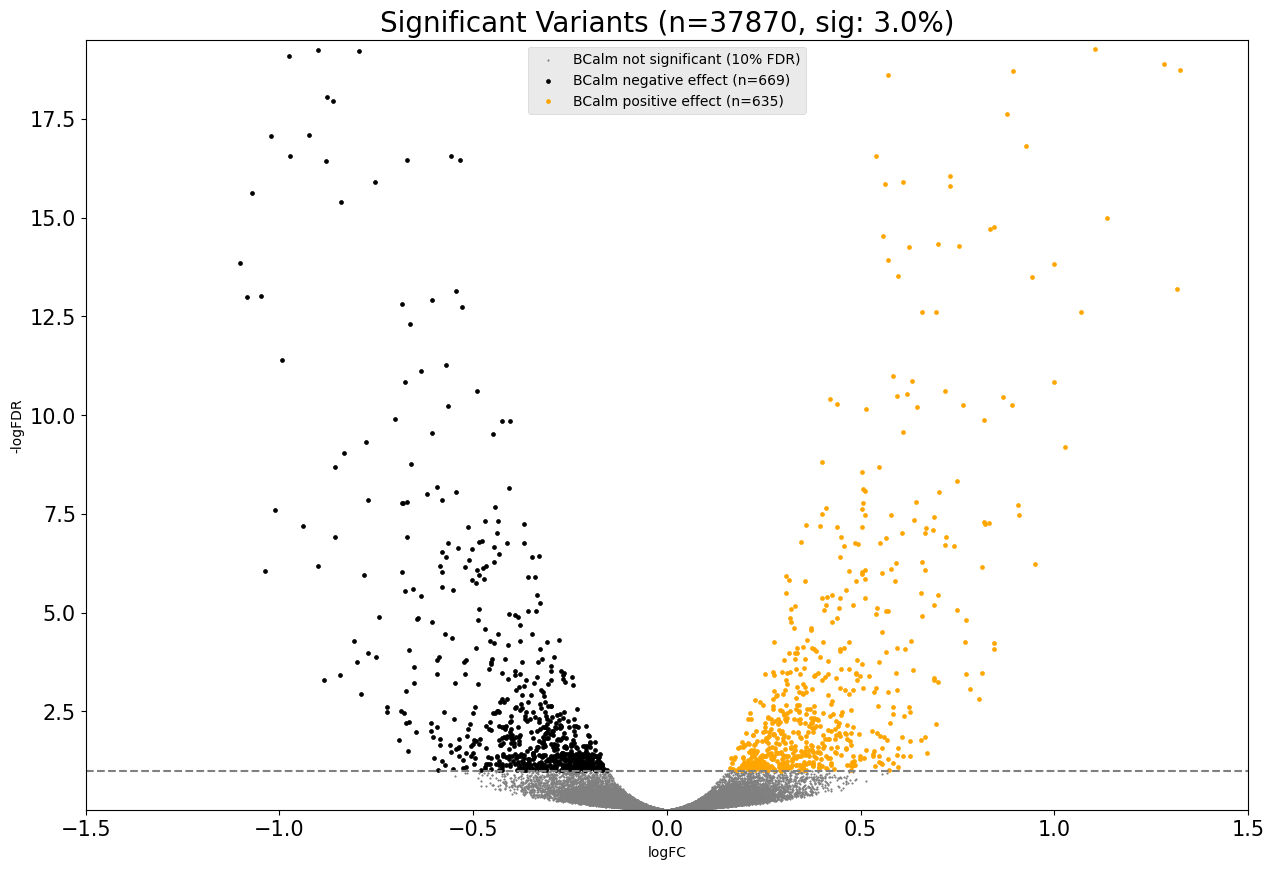

In [85]:
plot_volcano(variant_info_80k_gnomad_bcalm_exists, "Significant Variants", logFC_col="bcalm_variant_effect_log_ratio_activity", adj_p_val_col="bcalm_variant_effect_adjusted_p_value", significants_niveau=0.1, xlim_min=-1.5, xlim_max=1.5, ylim_min=0.01, ylim_max=19.5)

#### Group the variants by their effect size: strong activator, strong repressor, moderate effects
- General composition:
    - Plot the expected baseline distribution of all common variants and the randomly selected variants
    - Only all common variants 
- Plot the composition with respect to the allele frequency
    - (common: MAF >=5%, low-frequency: <5% - 1%, rare: <1% - 0.1%, ultra-rare: <0.1%, singletons: AC==1) Kari Strouse

In [ ]:
variant_info_80k_gnomad_bcalm_exists.columns
variant_info_80k_gnomad_bcalm_exists.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'is_significant_NGN2', 'BCalm_true', 'variant_group'],
      dtype='object')

In [ ]:
variant_info_80k_gnomad_bcalm_exists["bcalm_variant_effect_log_ratio_activity"].describe()


count    37870.000000
mean        -0.003595
std          0.145283
min         -1.345649
25%         -0.081613
50%         -0.004067
75%          0.073227
max          1.457050
Name: bcalm_variant_effect_log_ratio_activity, dtype: float64

#### Group the activity values

In [137]:
def get_variant_effect_direction(row, variant_effect):
    """
    Classify variant effects based on the logFC value.
    """
    logFC = row[variant_effect]
    if logFC > 0:
        return "positive"
    elif logFC < 0:
        return "negative"
    else:
        return "neutral"

def get_variant_effect_size_group(row, variant_effect, adj_pvalue, positive_threshold=0.5, negative_threshold=-0.5, significant_threshold=0.1):
    """
    Classify variant effects into groups based on the logFC value: strong activator, strong repressor, moderate effects
    """
    adj_pvalue = row[adj_pvalue]
    if adj_pvalue >= significant_threshold:
        return "not significant"
    logFC = row[variant_effect]
    if logFC >= positive_threshold:
        return "strong activator"
    elif logFC <= negative_threshold:
        return "strong repressor"
    else:
        return "moderate effect"

In [ ]:
variant_info_80k_gnomad_bcalm_exists['variant_effect_direction'] = variant_info_80k_gnomad_bcalm_exists.apply(lambda row: get_variant_effect_direction(row, variant_effect_logfc_col), axis=1)
variant_info_80k_gnomad_bcalm_exists

In [ ]:
# identify the median value of the variant effect of significant results:
# add an absolute value result:
variant_info_80k_gnomad_bcalm_exists["abs_bcalm_variant_effect_log_ratio_activity"] = variant_info_80k_gnomad_bcalm_exists[f"{variant_effect_logfc_col}"].abs()
median_absolute_variant_effect = variant_info_80k_gnomad_bcalm_exists.loc[variant_info_80k_gnomad_bcalm_exists[f"{is_significant_ngn2_col}"]][f"abs_bcalm_variant_effect_log_ratio_activity"].median()
print(f"Median absolute variant effect of significant results: {median_absolute_variant_effect}")

# ~ log2(1.282) = 0.3586 => median absolute variant effects is equal to 1.282 fold change

Median absolute variant effect of significant results: 0.3586128396091355


In [ ]:
# Get the median variant effect of significant variants for positive and negative effect directions
median_positive_effect = variant_info_80k_gnomad_bcalm_exists.loc[(variant_info_80k_gnomad_bcalm_exists[f"{is_significant_ngn2_col}"]) & (variant_info_80k_gnomad_bcalm_exists['variant_effect_direction'] == 'positive')][f"{variant_effect_logfc_col}"].median()
median_negative_effect = variant_info_80k_gnomad_bcalm_exists.loc[(variant_info_80k_gnomad_bcalm_exists[f"{is_significant_ngn2_col}"]) & (variant_info_80k_gnomad_bcalm_exists['variant_effect_direction'] == 'negative')][f"{variant_effect_logfc_col}"].median()

print(f"Median positive variant effect of significant results: {median_positive_effect}")
print(f"Median negative variant effect of significant results: {median_negative_effect}")

# log2(1.29) = 0.37106163

Median positive variant effect of significant results: 0.371061639763656
Median negative variant effect of significant results: -0.346726788832914


In [138]:
variant_info_80k_gnomad_bcalm_exists['variant_effect_size_group'] = variant_info_80k_gnomad_bcalm_exists.apply(lambda row: get_variant_effect_size_group(row, variant_effect_logfc_col, adj_pvalue=variant_effect_adjusted_p_val_col, positive_threshold=median_positive_effect, negative_threshold=median_negative_effect, significant_threshold=significant_threshold), axis=1)
variant_info_80k_gnomad_bcalm_exists['variant_effect_size_group'].value_counts()

variant_effect_size_group
not significant     36566
moderate effect       651
strong repressor      335
strong activator      318
Name: count, dtype: int64

In [ ]:
variant_info_80k_gnomad_bcalm_exists

In [139]:
variant_info_80k_gnomad_bcalm_exists_significant = variant_info_80k_gnomad_bcalm_exists.loc[variant_info_80k_gnomad_bcalm_exists[f"{is_significant_ngn2_col}"]].copy()
variant_info_80k_gnomad_bcalm_exists_significant

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,bcalm_alternative_log_ratio_activity,label,gnomad_AC,gnomad_AF,is_significant_NGN2,BCalm_true,variant_group,abs_bcalm_variant_effect_log_ratio_activity,variant_effect_direction,variant_effect_size_group
52,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGGAGCGCCCAGCAGGTGTCCAGCGGTGCTGGCGCTGCCTCTGTCT...,GGGAGCGCCCAGCAGGTGTCCAGCGGTGCTGGCGCTGCCTCTGTCT...,[232],True,2.278011e-03,0.543880,1.000000e+00,...,0.015594,cardiac_neuro_cava_random,17.0,0.000112,True,positive,ultra-rare,0.543880,positive,strong activator
98,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[85],True,1.063292e-02,0.337798,1.000000e+00,...,0.079893,cardiac_neuro_cava_random,1.0,0.000007,True,positive,singleton,0.337798,positive,moderate effect
99,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],True,2.354474e-18,0.877785,1.000000e+00,...,0.186480,cardiac_neuro_cava_random,16.0,0.000105,True,positive,ultra-rare,0.877785,positive,strong activator
210,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,TGGTGGGGACCTGGGGCTCTCAGAGGATCTGTTGGGGCGGGGAGAT...,TGGTGGGGACCTGGGGCTCTCAGAGGATCTGTTGGGGCGGGGAGAT...,[141],True,5.335390e-02,-0.526124,1.000000e+00,...,-0.034562,cardiac_neuro_cava_random,54371.0,0.357779,True,negative,common,0.526124,negative,strong repressor
240,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,GGCTCTTTGCATGTCTCTGGGAAAACCTGATCAGCTGACCCAAACC...,GGCTCTTTGCATGTCTCTGGGAAAACCTGATCAGCTGACCCAAACC...,[60],True,2.490829e-08,-1.011462,1.000000e+00,...,-0.100917,cardiac_neuro_cava_random,21925.0,0.144052,True,negative,common,1.011462,negative,strong repressor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46153,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,CACCCTGGCTCTGAGGGGAGACCCACAAAGCAACTTTCTGTTGAGA...,CACCCTGGCTCTGAGGGGAGACCCACAAAGCAACTTTCTGTTGAGA...,[117],True,4.614440e-04,0.436432,1.000000e+00,...,-0.000981,cardiac_neuro_cava_random,34.0,0.000303,True,positive,ultra-rare,0.436432,positive,strong activator
46169,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],True,7.565204e-03,0.366324,3.143962e-25,...,0.243131,cardiac_neuro_cava_random,10.0,0.000090,True,positive,ultra-rare,0.366324,positive,moderate effect
46328,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AAAATCTTGTCACTCTTAATTTTTCCTTTCTTATGTCTGCCTTTTC...,AAAATCTTGTCACTCTTAATTTTTCCTTTCTTATGTCTGCCTTTTC...,[138],True,9.778068e-02,0.180138,1.000000e+00,...,0.053101,cardiac_neuro_cava_random,2.0,0.000018,True,positive,ultra-rare,0.180138,positive,moderate effect
46329,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AAAATCTTGTCACTCTTAATTTTTCCTTTCTTATGTCTGCCTTTTC...,AAA

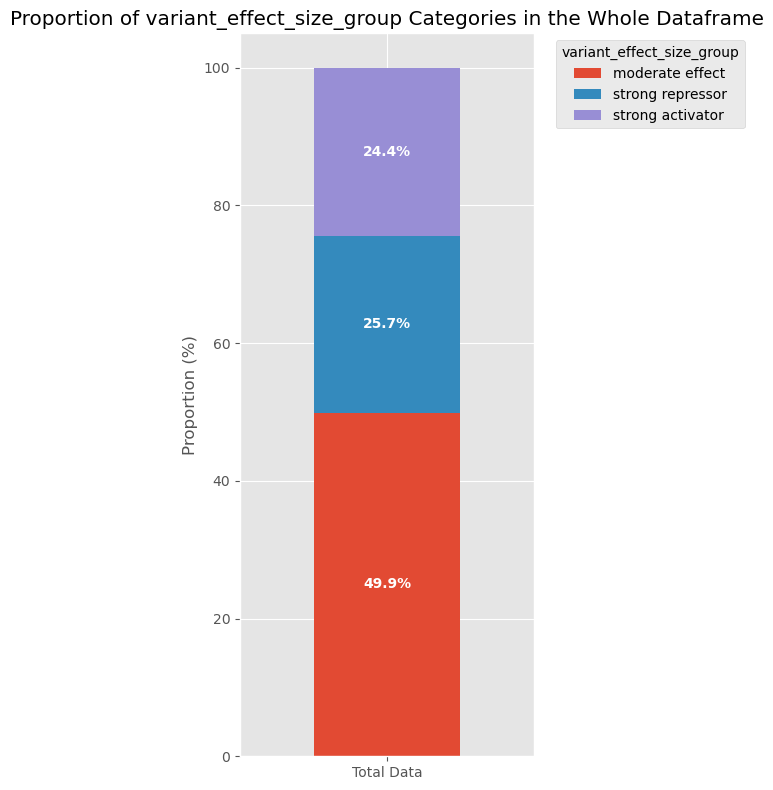

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the custom column name
custom_name = 'variant_effect_size_group'

# Calculate the proportions of each category in the custom_name column
proportions = variant_info_80k_gnomad_bcalm_exists_significant[custom_name].value_counts(normalize=True) * 100

# Create a DataFrame for plotting, with proportions as a single row
proportions_df = pd.DataFrame(proportions.values.reshape(1, -1), columns=proportions.index)
proportions_df.index = ['Total Data']

# Plot the stacked bar chart of proportions
fig, ax = plt.subplots(figsize=(6, 8))
proportions_df.plot(kind='bar', stacked=True, ax=ax, rot=0)

# Set plot titles and labels
ax.set_title(f'Proportion of {custom_name} Categories in the Whole Dataframe')
ax.set_xlabel('')
ax.set_ylabel('Proportion (%)')

# Add legend and percentages on top of the bars
for container in ax.containers:
    labels = [f'{w:.1f}%' for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold')

plt.legend(title=custom_name, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure
# plt.savefig('proportional_stacked_bar_chart.png')
# plt.close()
plt.show()

In [154]:
variant_info_80k_gnomad_bcalm_exists_significant['variant_group'].unique()

array(['ultra-rare', 'singleton', 'common', 'low-frequency', 'rare'],
      dtype=object)

In [162]:
def plot_variant_proportions(df, custom_name='custom_column', variant_group_col='variant_group'):
    """
    Plots a stacked bar chart showing the proportion of categories in a custom column
    for the total data, common variants, and more rare variants, with counts.

    Args:
        df (pd.DataFrame): The input DataFrame.
        custom_name (str): The name of the column to plot proportions for (e.g., 'CADD_category').
        variant_group_col (str): The name of the column used for filtering into
                                 'common' and 'rare' variant groups.
    """
    # Define the filter functions internally
    def filter_for_common_variants(df):
        return df[variant_group_col].isin(["common", "low-frequency"])

    def filter_for_more_rare_variants(df):
        return df[variant_group_col].isin(["rare", "ultra-rare", "singleton"])

    # Apply the filter to get the filtered dataframes
    filtered_common_variants = df[filter_for_common_variants(df)]
    filtered_more_rare_variants = df[filter_for_more_rare_variants(df)]

    # Calculate the proportions for the total and filtered data
    proportions_total = df[custom_name].value_counts(normalize=True) * 100
    proportions_common_variants = filtered_common_variants[custom_name].value_counts(normalize=True) * 100
    proportions_more_rare_variants = filtered_more_rare_variants[custom_name].value_counts(normalize=True) * 100

    # Combine the proportions into a single dataframe for plotting
    combined_proportions = pd.concat([proportions_total, proportions_common_variants, proportions_more_rare_variants], axis=1, sort=False).T
    combined_proportions.index = ['Total Data', 'Common variants', 'Rare to singleton variants']
    combined_proportions.fillna(0, inplace=True)

    # Calculate the total number of variants for each group
    counts = [len(df), len(filtered_common_variants), len(filtered_more_rare_variants)]

    # Plot the stacked bar chart
    fig, ax = plt.subplots(figsize=(10, 7))
    combined_proportions.plot(kind='bar', stacked=True, ax=ax, rot=32)

    # Set plot titles and labels
    ax.set_title(f'Proportion of {custom_name} in Total Data vs Among common variants vs Among more rare variants')
    ax.set_xlabel('')
    ax.set_ylabel('Proportion (%)')

    # Add legend and percentages on top of the bars
    for container in ax.containers:
        labels = [f'{w:.1f}%' if w > 0 else '' for w in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold')

    # Add the overall number of variants to the top of each bar
    for i, count in enumerate(counts):
        ax.text(i, 102, f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.legend(title=custom_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    # # Save the figure
    # plt.savefig('proportional_stacked_bar_chart_with_counts.png')
    # plt.close()

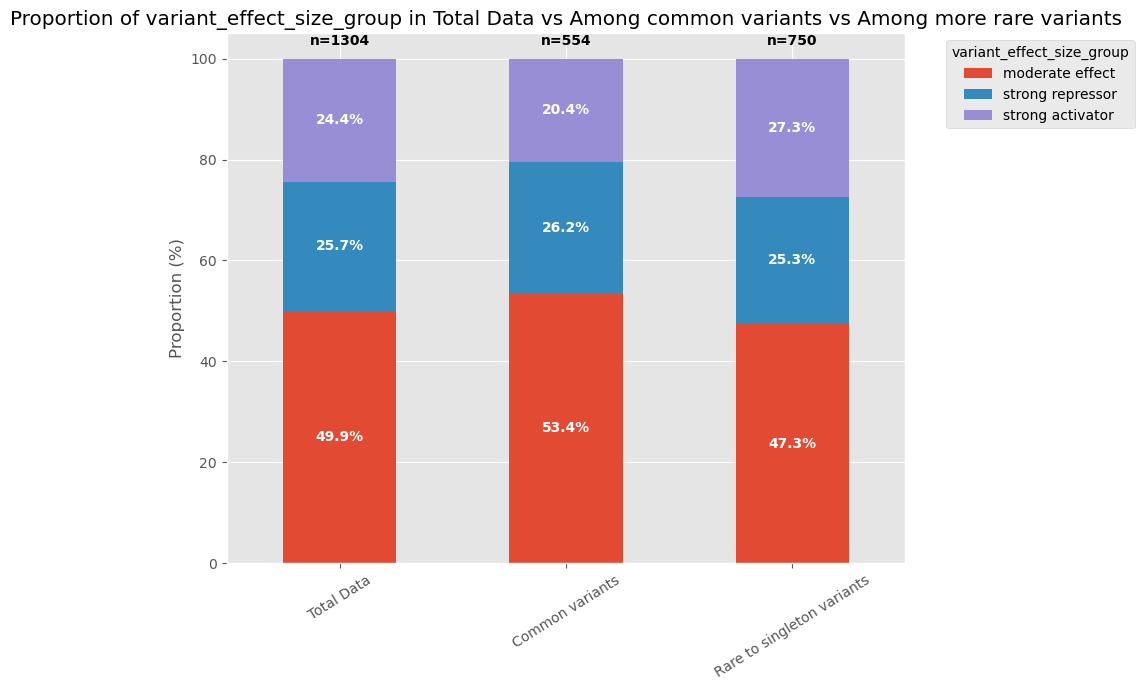

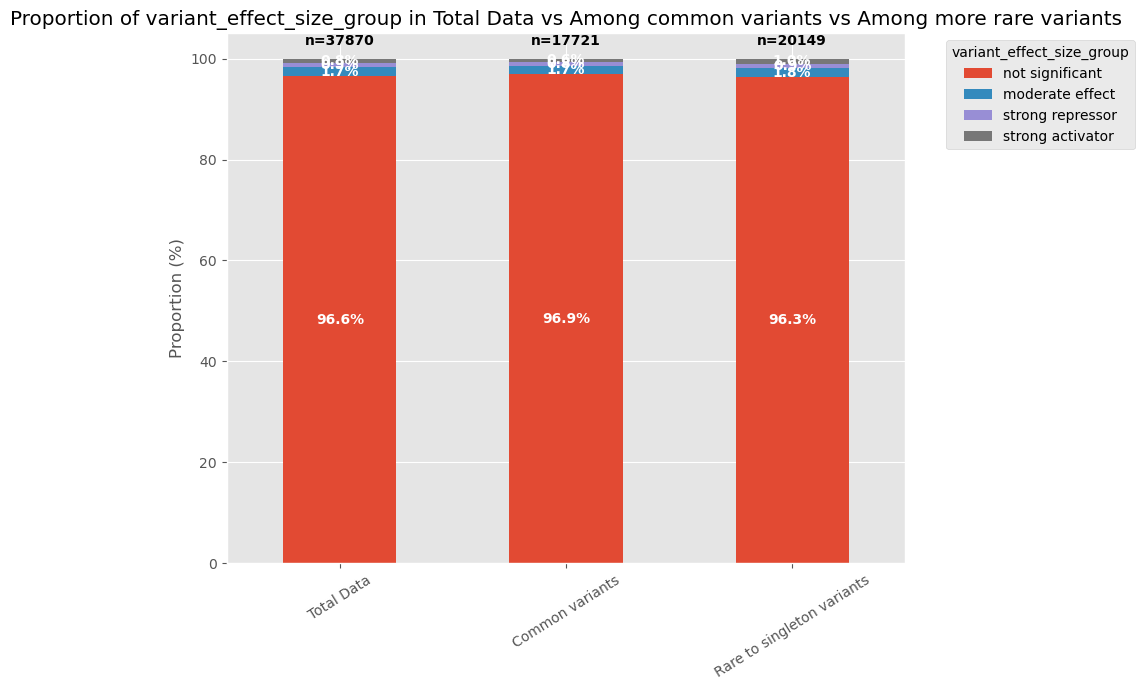

In [ ]:
plot_variant_proportions(
    df=variant_info_80k_gnomad_bcalm_exists_significant,
    custom_name='variant_effect_size_group',
    variant_group_col='variant_group'
)

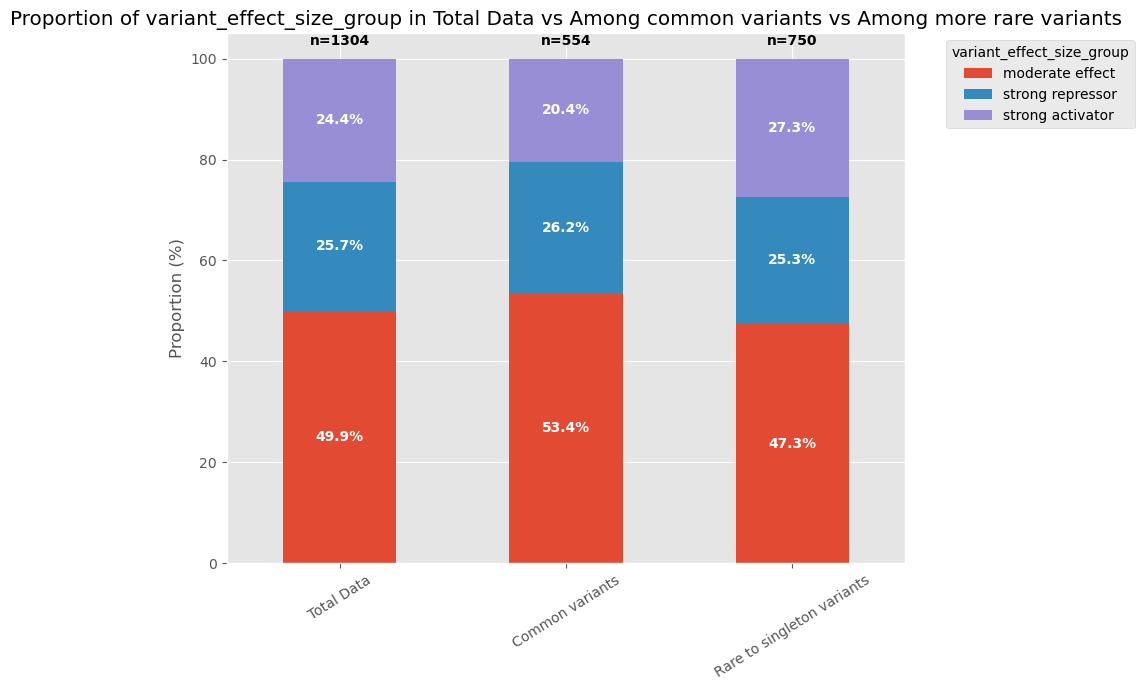

In [159]:
# Define the filter functions
def filter_for_common_variants(df):
    return df['variant_group'].isin(["common", "low-frequency"])

def filter_for_more_rare_variants(df):
    return df['variant_group'].isin(["rare", "ultra-rare", "singleton"])

# Apply the filter to get the filtered dataframes
filtered_common_variants = variant_info_80k_gnomad_bcalm_exists_significant[filter_for_common_variants(variant_info_80k_gnomad_bcalm_exists_significant)]
filtered_more_rare_variants = variant_info_80k_gnomad_bcalm_exists_significant[filter_for_more_rare_variants(variant_info_80k_gnomad_bcalm_exists_significant)]

# Calculate the proportions for the total and filtered data
proportions_total = variant_info_80k_gnomad_bcalm_exists_significant[custom_name].value_counts(normalize=True) * 100
proportions_common_variants = filtered_common_variants[custom_name].value_counts(normalize=True) * 100
proportions_more_rare_variants = filtered_more_rare_variants[custom_name].value_counts(normalize=True) * 100

# Combine the proportions into a single dataframe for plotting
combined_proportions = pd.concat([proportions_total, proportions_common_variants, proportions_more_rare_variants], axis=1, sort=False).T
combined_proportions.index = ['Total Data', 'Common variants', 'Rare to singleton variants']
combined_proportions.fillna(0, inplace=True)

# Calculate the total number of variants for each group
total_count = len(variant_info_80k_gnomad_bcalm_exists_significant)
common_count = len(filtered_common_variants)
rare_count = len(filtered_more_rare_variants)
counts = [total_count, common_count, rare_count]

# Plot the stacked bar chart with three bars
fig, ax = plt.subplots(figsize=(10, 7))
combined_proportions.plot(kind='bar', stacked=True, ax=ax, rot=32)

# Set plot titles and labels
ax.set_title(f'Proportion of {custom_name} in Total Data vs Among common variants vs Among more rare variants')
ax.set_xlabel('')
ax.set_ylabel('Proportion (%)')

# Add legend and percentages on top of the bars
for container in ax.containers:
    labels = [f'{w:.1f}%' if w > 0 else '' for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold')

# Add the overall number of variants to the top of each bar
for i, count in enumerate(counts):
    ax.text(i, 102, f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.legend(title=custom_name, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Investigate the Allele Frequency of the variants

In [120]:
import seaborn as sns
def plot_violin_with_group(count_df, labels_list, save_path=None, alternative_labels=None, colors=None, color_col=None):
    """Plot a violin plot just for a subset of labels
    @colors: dict of colors for each label
    """
    subset_rep_label_df = count_df[count_df[f"{color_col}"].isin(labels_list)]
    avg_seq_per_label = int(subset_rep_label_df.groupby(f"{color_col}").count()["name"].mean())

    fig, ax = plt.subplots(figsize=(10,8))
    ax.set_title(f'Log2 for {len(labels_list)} labels and average number of sequences per label is {avg_seq_per_label}')
    if colors:
        sns.violinplot(x=subset_rep_label_df[f"{color_col}"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df[f"{color_col}"], ax=ax, palette=colors)
    else:
        sns.violinplot(x=subset_rep_label_df[f"{color_col}"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df[f"{color_col}"], ax=ax)

    if alternative_labels:
        # add alternative labels
        ax.set_xticklabels(alternative_labels)
    plt.xticks(rotation=90)
    ax.set_xlabel('Label')
    ax.set_ylabel('log2(RNA/DNA)')
    # add line at 0
    ax.axhline(y=0, color='black', linestyle='--')
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight') # bbox_inches='tight' to prevent cutting off labels

def plot_violin(count_df, x_column_of_interest="log2", y_column_of_interest="variant_group", save_path=None, custom_order=None, colors=None, color_col=None):
    """Plot a violin plot just for a subset of labels
    @colors: dict of colors for each label
    """

    fig, ax = plt.subplots(figsize=(10,8))

    if custom_order:
        sns.violinplot(data=count_df, x=f"{x_column_of_interest}", y=f"{y_column_of_interest}", ax=ax, order=custom_order)
    else:
        sns.violinplot(data=count_df, x=f"{x_column_of_interest}", y=f"{y_column_of_interest}", ax=ax)

    plt.xticks(rotation=90)
    ax.set_xlabel('Label')
    ax.set_ylabel('log2(RNA/DNA)')
    # add line at 0
    ax.axhline(y=0, color='black', linestyle='--')
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight') # bbox_inches='tight' to prevent cutting off labels


In [ ]:
def get_variant_AF_group(row, af_col='AF', ac_col='AC'):
    """
    Classify the variant into different AF groups based on the AF and AC values.
    """
    if pd.isna(row[af_col]) or pd.isna(row[ac_col]):
        raise ValueError("AF or AC column contains NaN values, please check the input data.")
    af = row[af_col]
    ac = row[ac_col]
    if ac == 1:
        return "singleton"
    elif af < 0.001:
        return "ultra-rare"
    elif af >= 0.001 and af < 0.01:
        return "rare"
    elif af >= 0.01 and af < 0.05:
        return "low-frequency"
    elif af >= 0.05:
        return "common"
    else:
        raise ValueError("Unexpected AF value encountered. Please check the input data.")

In [ ]:
variant_info_80k_gnomad_bcalm_exists['variant_group'] = variant_info_80k_gnomad_bcalm_exists.apply(lambda row: get_variant_AF_group(row, af_col='gnomad_AF', ac_col='gnomad_AC'), axis=1)

In [ ]:
# violinplot of the activity
custom_order = ['common', 'low-frequency', 'rare', 'ultra-rare', 'singleton']
sns.violinplot(data=variant_info_80k_gnomad_bcalm_exists, x="variant_group", y="bcalm_variant_effect_log_ratio_activity", order=custom_order)


In [ ]:
variant_info_80k_gnomad_bcalm_exists["variant_group"].unique()

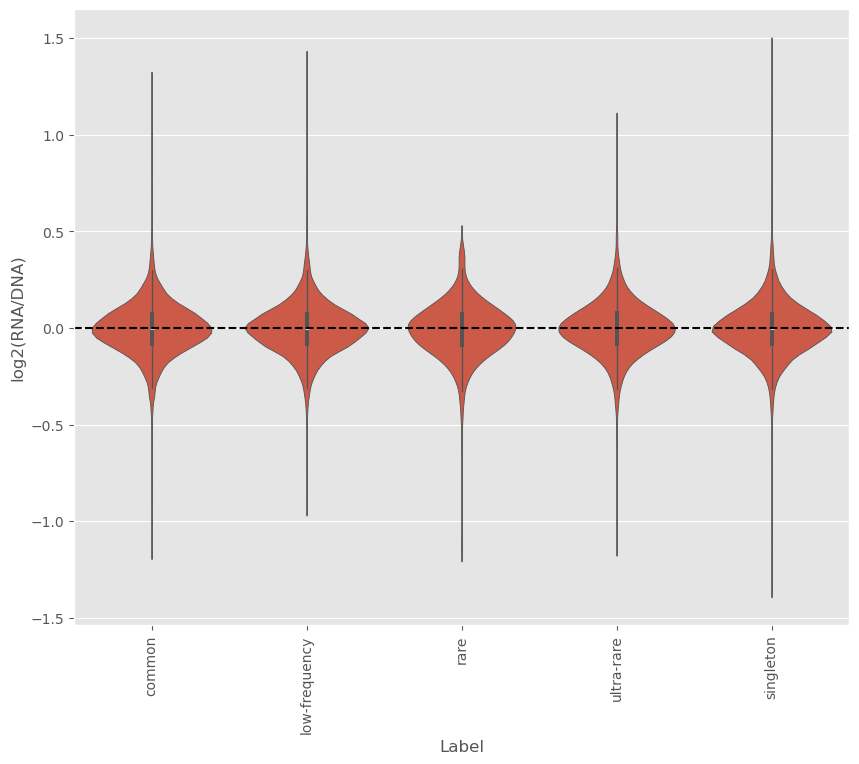

In [121]:
# plot_subgroup_violin(variant_info_80k_gnomad_bcalm_exists, labels_without_DNase, "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/activity_distri_without_DNase.png", None, None)
# plot_violin(variant_info_80k_gnomad_bcalm_exists, x_column_of_interest="bcalm_variant_effect_log_ratio_activity", y_column_of_interest="variant_group", save_path=None, alternative_labels=None, colors=None, color_col=None)
custom_order = ['common', 'low-frequency', 'rare', 'ultra-rare', 'singleton']

plot_violin(variant_info_80k_gnomad_bcalm_exists, x_column_of_interest="variant_group", y_column_of_interest="bcalm_variant_effect_log_ratio_activity", save_path=None, custom_order=custom_order, colors=None, color_col=None)


In [ ]:
variant_info_80k_gnomad_significant = variant_info_80k_gnomad_bcalm_exists.loc[variant_info_80k_gnomad_bcalm_exists[f"{is_significant_ngn2_col}"]].copy()

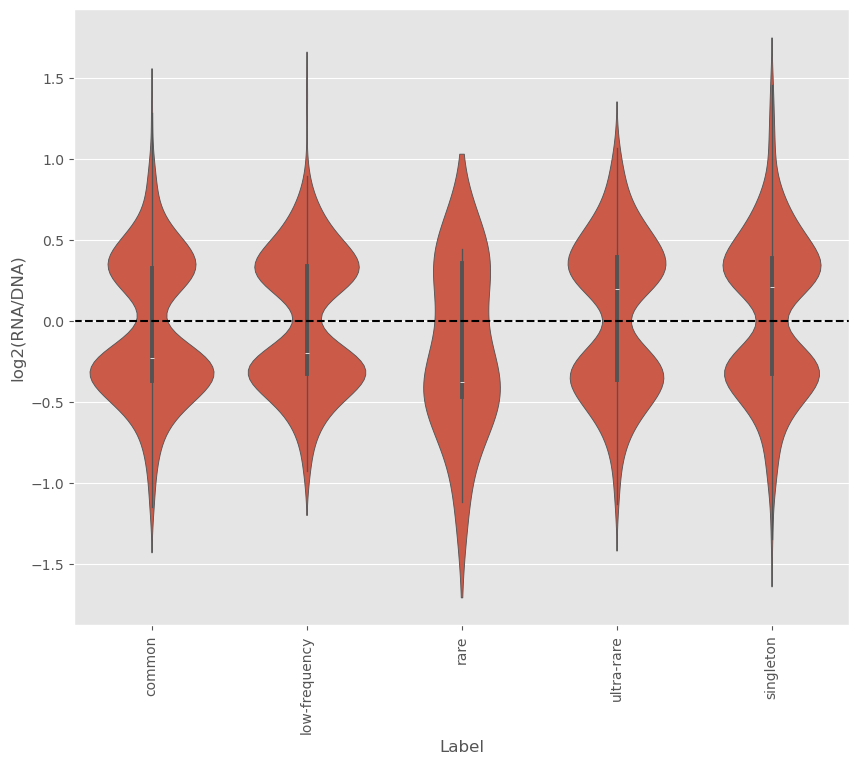

In [123]:
# plot_subgroup_violin(variant_info_80k_gnomad_bcalm_exists, labels_without_DNase, "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/activity_distri_without_DNase.png", None, None)
# plot_violin(variant_info_80k_gnomad_bcalm_exists, x_column_of_interest="bcalm_variant_effect_log_ratio_activity", y_column_of_interest="variant_group", save_path=None, alternative_labels=None, colors=None, color_col=None)
custom_order = ['common', 'low-frequency', 'rare', 'ultra-rare', 'singleton']

plot_violin(variant_info_80k_gnomad_significant, x_column_of_interest="variant_group", y_column_of_interest="bcalm_variant_effect_log_ratio_activity", save_path=None, custom_order=custom_order, colors=None, color_col=None)


In [96]:
variant_info_80k_gnomad_bcalm_exists['variant_group'].value_counts()

variant_group
singleton        10104
common            9836
ultra-rare        9586
low-frequency     7885
rare               459
Name: count, dtype: int64

In [ ]:
# investigate the variant groups based on their allele frequency:
# violinplot of the activity

sns.violinplot(data=variant_info_80k_gnomad_bcalm_exists, x="variant_group", y="bcalm_variant_effect_log_ratio_activity")
# set custom x-axis labels


#### Are functional variants enriched in specific types of CREs (e.g., promoters vs. enhancers)?